# 02. Baseline Text Classification with TF-IDF and Logistic Regression


## 1. What you will build

- A production-style baseline classifier for support intent routing.
- A full training/evaluation workflow with TF-IDF + Logistic Regression.
- An inference helper to return predicted label probabilities for new tickets.


## 2. When to use this in real companies

Use this approach when you need a strong, low-cost baseline for triage systems, CRM routing, or ticket queue automation. It is especially useful when explainability, retraining speed, and low serving latency are business requirements.


## 3. Business goal

Classify incoming support tickets into `billing`, `technical`, `account_access`, and `shipping` so operations teams can route issues automatically.


## 4. Imports and setup


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


## 5. Load dataset from `data/02_data`


In [2]:
DATA_PATH = Path("../data/02_data/support_tickets_baseline.csv")
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["text", "label"]).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Classes: {df['label'].nunique()}")

df.head()

Rows: 1,400
Classes: 4


,ticket_id,text,label
0,CLS-00001,"Need assistance, The invoice total is incorrec...",billing
1,CLS-00002,"Good morning, The invoice total is incorrect. ...",billing
2,CLS-00003,"Need assistance, Courier delivered to the wron...",shipping
3,CLS-00004,"Hello support, Export to CSV does not work. Re...",technical
4,CLS-00005,"Good morning, The payment failed but money was...",billing


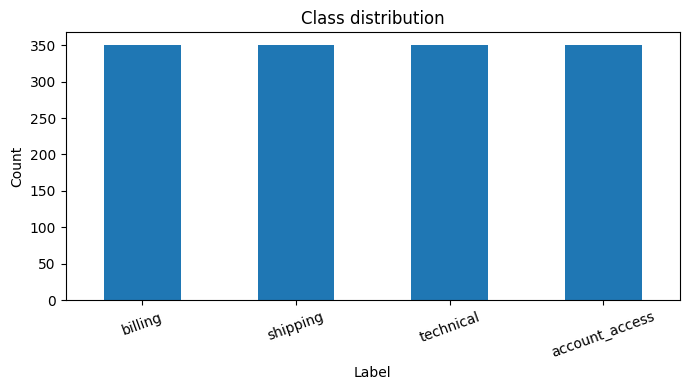

In [3]:
ax = df["label"].value_counts().plot(kind="bar", figsize=(7, 4), title="Class distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Train/test split

We split before fitting TF-IDF to avoid data leakage.


In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")

Train rows: 1120
Test rows:  280


## 7. Train the baseline model


In [5]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        ),
    ),
    ("logreg", LogisticRegression(max_iter=2000, n_jobs=None)),
])

model.fit(train_df["text"], train_df["label"])
preds = model.predict(test_df["text"])
probs = model.predict_proba(test_df["text"])

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Cosine Similarity vs Logistic Regression</title>
  <style>
    body {
      font-family: Arial, sans-serif;
      background-color: #0f172a;
      color: #e5e7eb;
      margin: 40px;
    }

    h2 {
      color: #f8fafc;
      margin-bottom: 18px;
      font-size: 28px;
      letter-spacing: 0.5px;
    }

    .table-container {
      overflow-x: auto;
    }

    table {
      width: 100%;
      border-collapse: collapse;
      background-color: #111827;
      border: 1px solid #334155;
      border-radius: 10px;
      overflow: hidden;
    }

    thead {
      background-color: #1e3a8a;
    }

    thead th {
      color: #ffffff;
      text-align: left;
      padding: 14px 16px;
      font-size: 15px;
      border-bottom: 1px solid #334155;
    }

    tbody tr:nth-child(odd) {
      background-color: #1f2937;
    }

    tbody tr:nth-child(even) {
      background-color: #111827;
    }

    tbody td {
      padding: 14px 16px;
      border-bottom: 1px solid #334155;
      vertical-align: top;
      color: #e5e7eb;
      line-height: 1.5;
    }

    tbody td:first-child {
      font-weight: bold;
      color: #ffffff;
      width: 18%;
      white-space: nowrap;
    }

    code {
      background-color: #334155;
      color: #f8fafc;
      padding: 2px 6px;
      border-radius: 4px;
      font-size: 90%;
    }
  </style>
</head>
<body>
  <h2>COSINE SIMILARITY vs LOGISTIC REGRESSION</h2>

  <div class="table-container">
    <table>
      <thead>
        <tr>
          <th>Aspect</th>
          <th>Cosine Similarity</th>
          <th>Logistic Regression</th>
        </tr>
      </thead>
      <tbody>
        <tr>
          <td>Definition</td>
          <td>A similarity-based method that measures the angle between two document vectors and identifies the most similar training example.</td>
          <td>A supervised machine learning algorithm that learns the relationship between input features and class labels to predict the most probable category.</td>
        </tr>
        <tr>
          <td>Type of approach</td>
          <td>Instance-based / similarity-based approach.</td>
          <td>Supervised classification model.</td>
        </tr>
        <tr>
          <td>How it works</td>
          <td>Compares each test document against all training documents and assigns the label of the most similar one.</td>
          <td>Learns feature weights from labeled data and predicts the class with the highest probability.</td>
        </tr>
        <tr>
          <td>Training process</td>
          <td>No explicit model training; it relies on direct comparison with training examples.</td>
          <td>Requires a training phase to learn decision boundaries from the labeled dataset.</td>
        </tr>
        <tr>
          <td>Main strength</td>
          <td>Simple, intuitive, and useful for document retrieval or nearest-neighbor matching.</td>
          <td>Strong generalization ability and usually better performance in supervised text classification tasks.</td>
        </tr>
        <tr>
          <td>Main limitation</td>
          <td>Depends heavily on finding a very similar example in the training data.</td>
          <td>Requires labeled data and proper training to achieve good results.</td>
        </tr>
        <tr>
          <td>Best use case</td>
          <td>Retrieval systems, semantic matching, and similarity-based recommendations.</td>
          <td>Automatic text classification, sentiment analysis, spam detection, and supervised NLP tasks.</td>
        </tr>
        <tr>
          <td>Output</td>
          <td>Similarity score and label of the nearest training document.</td>
          <td>Predicted class and class probabilities using <code>predict_proba()</code>.</td>
        </tr>
      </tbody>
    </table>
  </div>
</body>
</html>

## 8. Evaluation


Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1-score:  1.000

Classification report:

                precision    recall  f1-score   support

account_access      1.000     1.000     1.000        70
       billing      1.000     1.000     1.000        70
      shipping      1.000     1.000     1.000        70
     technical      1.000     1.000     1.000        70

      accuracy                          1.000       280
     macro avg      1.000     1.000     1.000       280
  weighted avg      1.000     1.000     1.000       280



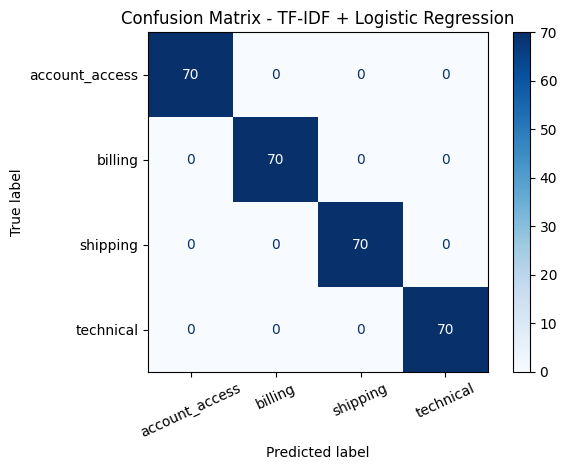

In [6]:
acc = accuracy_score(test_df["label"], preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_df["label"], preds, average="weighted")

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print("\nClassification report:\n")
print(classification_report(test_df["label"], preds, digits=3))

ConfusionMatrixDisplay.from_predictions(test_df["label"], preds, cmap="Blues", xticks_rotation=25)
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

## 9. Model interpretability (top terms per class)


In [7]:
tfidf = model.named_steps["tfidf"]
clf = model.named_steps["logreg"]
feature_names = tfidf.get_feature_names_out()

for i, cls in enumerate(clf.classes_):
    top_idx = clf.coef_[i].argsort()[-10:][::-1]
    print(f"\nTop terms for {cls}: {[feature_names[j] for j in top_idx]}")


Top terms for account_access: ['account', 'login', 'change login', 'email reported', 'login email', 'log account', 'log', 'account reported', 'factor code', 'factor']

Top terms for billing: ['invoice', 'charged', 'refund arrived', 'arrived reported', 'refund', 'code applied', 'applied reported', 'discount', 'applied', 'discount code']

Top terms for shipping: ['delivered', 'order', 'delivery', 'address', 'address reported', 'order delivered', 'delivered reported', 'arrived damaged', 'damaged', 'damaged reported']

Top terms for technical: ['dashboard', 'blank login', 'blank', 'dashboard blank', 'login reported', 'website slow', 'today reported', 'slow', 'slow today', 'website']


## 10. Inference function for production-style usage


In [8]:
def predict_ticket_intent(text: str):
    """Return predicted label and calibrated class probabilities for one input ticket."""
    pred = model.predict([text])[0]
    prob_vector = model.predict_proba([text])[0]
    prob_table = pd.DataFrame({
        "label": model.named_steps["logreg"].classes_,
        "probability": prob_vector,
    }).sort_values("probability", ascending=False).reset_index(drop=True)
    return pred, prob_table


sample_ticket = "I was charged after cancellation and need a corrected invoice"
pred_label, pred_table = predict_ticket_intent(sample_ticket)
print("Predicted label:", pred_label)
pred_table

Predicted label: billing


,label,probability
0,billing,0.933715
1,technical,0.022453
2,account_access,0.022377
3,shipping,0.021455


## 11. Summary

- Data is externalized under `data/02_data` for teaching and reproducibility.
- The workflow is production-oriented: split, train, evaluate, explain, infer.
- This baseline is suitable as a first deployment before moving to transformer models.
